# スマートマネー追跡 — 「一番儲かってる人2000アドレス」分析ノート

> **元ネタ (Twitterの実力者)**
> 「bot、というか仮想通貨の戦場選び、選球眼を養いたいなら defillama にのってるPJ全てを開いて
> 一番儲かってる人2000アドレスくらい収集してパクればいいと思うよ。今はAIあるし手動でワイとか
> やってた時代に比べれば楽やろ」

このノートはそれを実際にやったもの。**教材**として、各セクションに「何を見ているか」「どう読むか」を書いた。

## 構成 (元ツイートの分解)

| 節 | 工程 | データ |
|---|---|---|
| §1 | **戦場選び** — カネがどこに集まり、どこで動いているか | DefiLlama API (全プロトコル) |
| §2 | **選球眼** — その戦場で実際に勝っている2000人は誰か | Hyperliquid 公式リーダーボード |
| §3 | **手法解剖** — 勝ち組が「何を・いつ・どれだけ」売買しているか | 上位200人の直近30日 全約定 |
| §4 | **今の張り方** — スマートマネーの現在ポジション合算 | 上位200人の現在ポジション |
| §5 | **シグナル化** — 通知Botのロジックと過去30日の発火シミュレーション | §3の約定データ |

## データの出どころと再現方法

- データは `data/smart_money/` にある (GitHub Actions `smart-money.yml` が収集してコミット)。
- 更新したい時は GitHub → Actions → **Smart Money Collect** を手動実行するだけ。
- 全て公開API・認証不要・無料。DefiLlama自体には個人のPnLランキングは無いため、
  アドレス収集は perp 出来高最大の戦場 Hyperliquid の公式リーダーボードを使う
  (詳細は `docs/DEFILLAMA_GUIDE.md`)。

In [1]:
import gzip, json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

try:
    import matplotlib_fontja  # 日本語フォント (pip install matplotlib-fontja)
except ImportError:
    print("matplotlib-fontja 未導入: 日本語ラベルが豆腐になる場合は pip install matplotlib-fontja")

# ---- 配色 (光背景で検証済みのパレット) ----
C   = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
       "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]   # カテゴリ (固定順)
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#c3c2b7"
SEQ = LinearSegmentedColormap.from_list("seq_blue",
      ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e",
    "xtick.color": "#898781", "ytick.color": "#898781",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "font.size": 10,
})

DATA = Path("../data/smart_money") if Path("../data/smart_money").exists() else Path("data/smart_money")

meta = json.loads((DATA / "collect_meta.json").read_text())
print("収集時刻(JST):", meta["collected_at_jst"])
print("パラメータ:", meta["params"])
print("件数:", json.dumps(meta["counts"], ensure_ascii=False))

収集時刻(JST): 2026-07-03T15:18:02.230645+09:00
パラメータ: {'TOP_N_ADDRESSES': 2000, 'FILLS_N': 200, 'FILLS_DAYS': 30, 'RANK_WINDOW': 'month', 'MIN_ACCT_VALUE': 10000.0}
件数: {"protocols": 7775, "chains": 455, "dexs": 1191, "fees": 2363, "perp_coins": 231, "spot_pairs": 308, "leaderboard_total": 40015, "leaderboard_saved": 2000, "fills_addresses_ok": 200, "fills_addresses_fail": 0, "fills": 223889, "positions": 1022}


---
# §1 戦場選び — DefiLlamaで「カネの居場所」を俯瞰する

DefiLlama は 6,000 以上の DeFi プロトコルの TVL・出来高・手数料を無料で集計している。
戦場選びで見るべきは3つ:

1. **TVL (預かり資産)** — カネが「置かれている」場所。ただし置かれているだけで動いていない資金も多い。
2. **出来高 (DEX/Perp)** — カネが「動いている」場所。トレーダーの戦場はこっち。
3. **手数料/収益** — ユーザーが実際に金を払っている場所 = 本物の需要。

**読み方**: 「出来高・手数料が伸びている × TVLがまだ小さい」= 若くて熱い戦場。
「TVL巨大 × 手数料薄い」= 枯れた戦場。

プロトコル総数: 7,775 / チェーン総数: 455


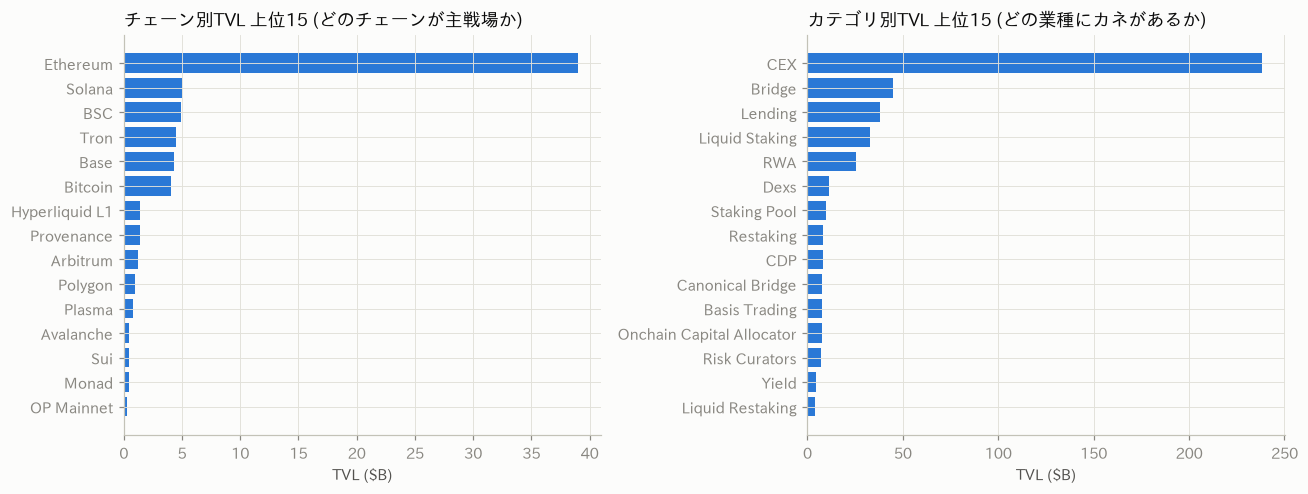

In [2]:
proto = pd.read_csv(DATA / "defillama_protocols.csv.gz")
chains = pd.read_csv(DATA / "defillama_chains.csv")
print(f"プロトコル総数: {len(proto):,} / チェーン総数: {len(chains):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

d = chains.nlargest(15, "tvl_usd").iloc[::-1]
axes[0].barh(d["chain"], d["tvl_usd"] / 1e9, color=BLUE)
axes[0].set_title("チェーン別TVL 上位15 (どのチェーンが主戦場か)", loc="left")
axes[0].set_xlabel("TVL ($B)")

cat = (proto.groupby("category")["tvl_usd"].sum()
            .nlargest(15).iloc[::-1])
axes[1].barh(cat.index, cat.values / 1e9, color=BLUE)
axes[1].set_title("カテゴリ別TVL 上位15 (どの業種にカネがあるか)", loc="left")
axes[1].set_xlabel("TVL ($B)")
plt.tight_layout()
plt.show()

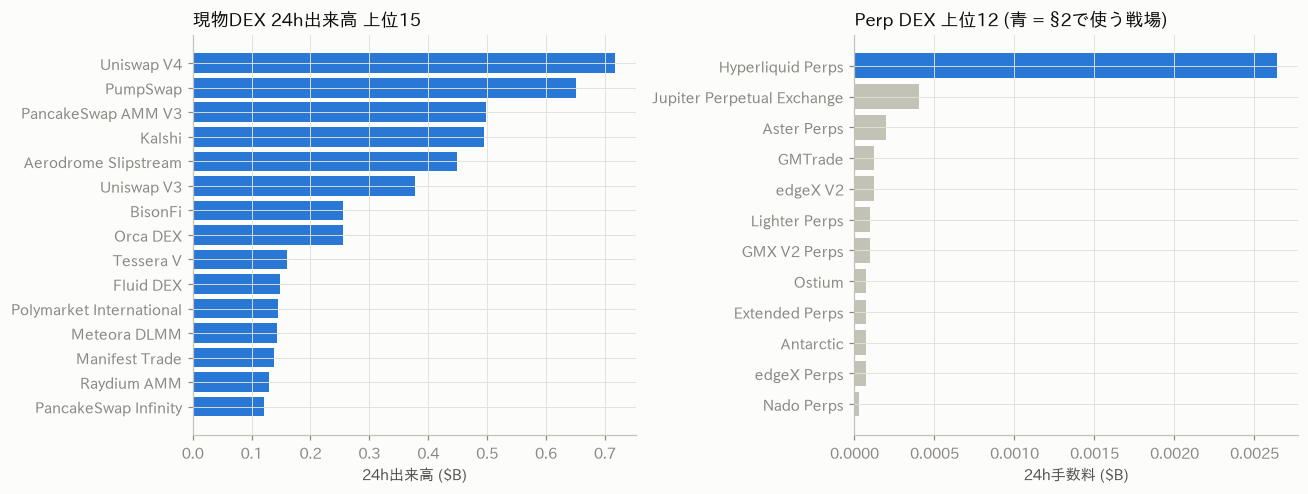

→ Hyperliquid系のperp24h手数料シェア: 63.4%  (perp戦場の中心。だからここの勝者を追う)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

dex = pd.read_csv(DATA / "defillama_dexs.csv")
d = dex.dropna(subset=["total_24h"]).nlargest(15, "total_24h").iloc[::-1]
axes[0].barh(d["name"], d["total_24h"] / 1e9, color=BLUE)
axes[0].set_title("現物DEX 24h出来高 上位15", loc="left")
axes[0].set_xlabel("24h出来高 ($B)")

perp_path = DATA / "defillama_perps.csv"
if perp_path.exists():
    perp = pd.read_csv(perp_path)
    xlabel = "24h出来高 ($B)"
else:
    # フォールバック: 手数料データのDerivativesカテゴリでperp戦場を比較
    perp = pd.read_csv(DATA / "defillama_fees.csv").query("category == 'Derivatives'")
    xlabel = "24h手数料 ($B)"
p = perp.dropna(subset=["total_24h"]).nlargest(12, "total_24h").iloc[::-1]
# 私たちがアドレス収集に使う戦場 (Hyperliquid) を強調、他はグレー
colors = [BLUE if "Hyperliquid" in n else GRAY for n in p["name"]]
axes[1].barh(p["name"], p["total_24h"] / 1e9, color=colors)
axes[1].set_title("Perp DEX 上位12 (青 = §2で使う戦場)", loc="left")
axes[1].set_xlabel(xlabel)
plt.tight_layout()
plt.show()

metric = "24h出来高" if perp_path.exists() else "24h手数料"
hl_share = perp.loc[perp["name"].str.contains("Hyperliquid", na=False), "total_24h"].sum() \
           / perp["total_24h"].sum() * 100
print(f"→ Hyperliquid系のperp{metric}シェア: {hl_share:.1f}%  "
      f"(perp戦場の中心。だからここの勝者を追う)")

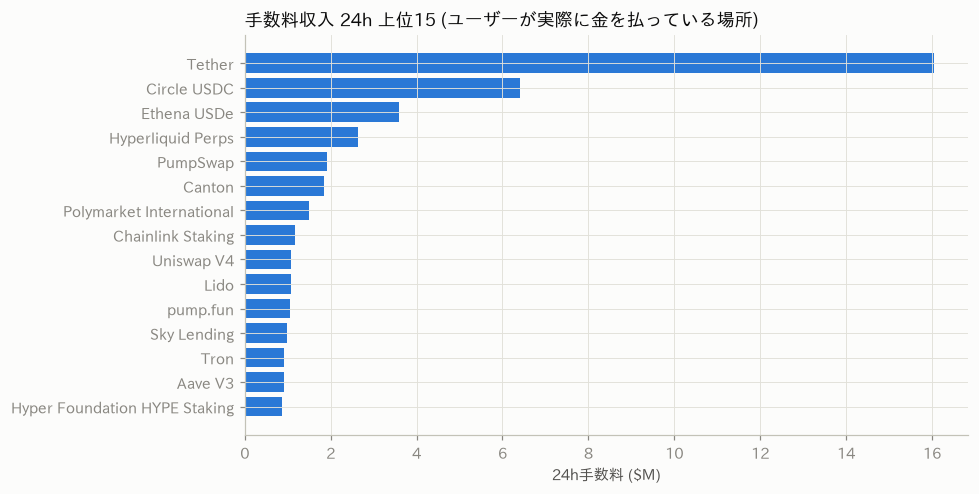

In [4]:
fees = pd.read_csv(DATA / "defillama_fees.csv")
d = fees.dropna(subset=["total_24h"]).nlargest(15, "total_24h").iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(d["name"], d["total_24h"] / 1e6, color=BLUE)
ax.set_title("手数料収入 24h 上位15 (ユーザーが実際に金を払っている場所)", loc="left")
ax.set_xlabel("24h手数料 ($M)")
plt.tight_layout()
plt.show()

**§1のまとめ (戦場選びの結論)**

- TVL・出来高・手数料の上位は毎期入れ替わる。**このノートを再収集するたびにこの3枚を見直す**のが「戦場選び」の習慣化。
- perp トレーダーとしての戦場は perp 出来高チャートがほぼ全て。上位1〜2箇所以外は流動性が薄く、勝者のデータも薄い。
- 新戦場の発見は DefiLlama の [Recent](https://defillama.com/recent) (新規上場PJ) と
  手数料の`change_7d`急伸を見る。ここは§5のBot拡張候補。

---
# §2 選球眼 — 「一番儲かってる人」2000アドレス

Hyperliquid 公式リーダーボード (`stats-data.hyperliquid.xyz/Mainnet/leaderboard`) は
**全ユーザー**の 日/週/月/全期間 の PnL・ROI・出来高を返す。
ここから**月間PnL上位2000アドレス**を抽出した (`leaderboard_top2000.csv`)。

**なぜ月間か**: 全期間PnLは「昔勝った人」を含み、日次は運の比重が大きすぎる。
月間は「いま勝っている」と「まぐれではない」のバランス。ただし生存バイアスがあるので
allTime も併記して照合する。

In [5]:
lb = pd.read_csv(DATA / "leaderboard_top2000.csv")
print(f"収集アドレス数: {len(lb):,} (全 {meta['counts'].get('leaderboard_total', '?'):,} ユーザーから抽出)")
total_pnl = lb["pnl_month"].sum()
print(f"上位{len(lb)}人の月間PnL合計: ${total_pnl:,.0f}")
lb.head(10)[["rank", "address", "display_name", "account_value",
             "pnl_month", "roi_month", "vlm_month", "pnl_allTime"]]

収集アドレス数: 2,000 (全 40,015 ユーザーから抽出)
上位2000人の月間PnL合計: $665,636,949


,rank,address,display_name,account_value,pnl_month,roi_month,vlm_month,pnl_allTime
0,1,0xe6111266afdcdf0b1fe8505028cc1f7419d798a7,NaN,9.611870e+08,8.726943e+07,0.099766,0.000000e+00,-5.000000e+02
1,2,0x17c3c8fdbcb7d1b240ce08965e09b1fc91cba868,NaN,2.402971e+07,1.479048e+07,0.427588,5.013103e+08,8.081987e+06
2,3,0xfc667adba8d4837586078f4fdcdc29804337ca06,NaN,6.976865e+07,1.324087e+07,0.147233,7.359058e+09,3.366867e+07
3,4,0xb3bd5fafb3dcb7ff0d27a6dcdb1974a2f8ac221d,NaN,7.029490e+07,1.107724e+07,0.187060,0.000000e+00,1.107724e+07
4,5,0x8cfac7c6f03e00db2f298699df96933a9694b6ab,NaN,9.769447e+06,9.105145e+06,13.706334,0.000000e+00,1.009795e+07
5,6,0x7fdafde5cfb5465924316eced2d3715494c517d1,BobbyBigSize,3.766777e+07,8.240072e+06,0.150991,1.517764e+09,1.857644e+08
6,7,0x4e23288cee4960f9f962195c22948e4bc7ae20c3,NaN,2.498549e+07,8.033906e+06,0.473933,2.200138e+09,1.164494e+07
7,8,0xfe7ce058edc7cfcde9ef8262ba51f8d4796ab7ae,NaN,1.728969e+07,7.796437e+06,0.288585,1.520130e+08,6.078826e+06
8,9,0x24de6b77e8bc31c40aa452926daa6bbab7a71b0f,NaN,2.048461e+09,7.671658e+06,0.003759,0.000000e+00,-5.000000e+02
9,10,0x0ddf9bae2af4b874b96d287a5ad42eb47138a902,Penision Fund,2.493060e+07,7.489023e+06,0.172393,4.381351e+08,4.269116e+07


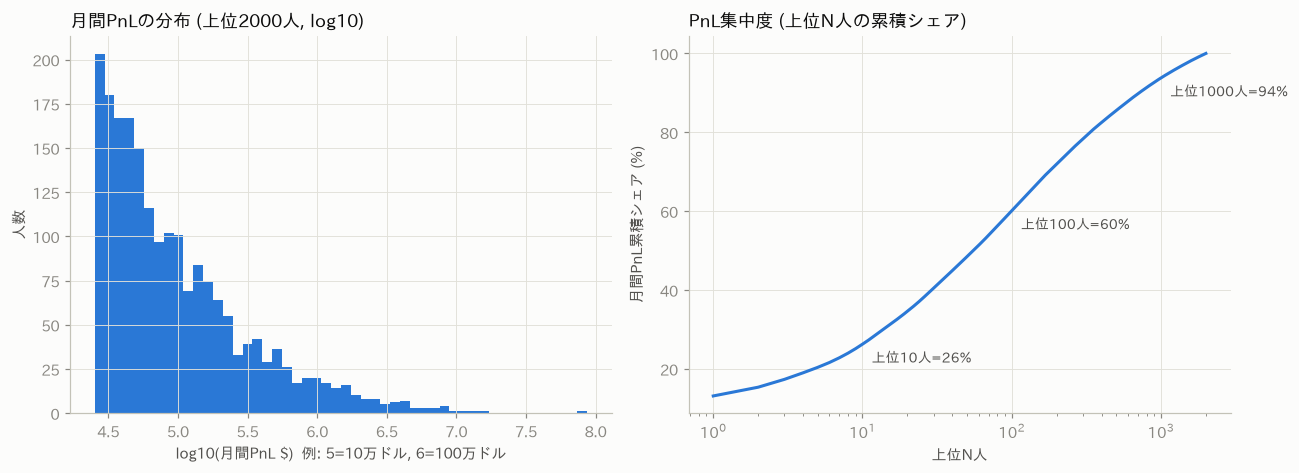

→ 上位10人で全体の26%、上位100人で60%。「2000人パクる」は実務上「上位100〜200人を深追いする」に等しい。


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# 月間PnLの分布 (右肩の異常な太さ = ごく少数が大半を稼ぐ)
axes[0].hist(np.log10(lb["pnl_month"].clip(lower=1)), bins=50, color=BLUE)
axes[0].set_title("月間PnLの分布 (上位2000人, log10)", loc="left")
axes[0].set_xlabel("log10(月間PnL $)  例: 5=10万ドル, 6=100万ドル")
axes[0].set_ylabel("人数")

# パレート曲線: 上位X人が全PnLの何%を占めるか
share = lb["pnl_month"].cumsum() / total_pnl * 100
axes[1].plot(range(1, len(lb) + 1), share, color=BLUE, lw=2)
axes[1].set_title("PnL集中度 (上位N人の累積シェア)", loc="left")
axes[1].set_xlabel("上位N人")
axes[1].set_ylabel("月間PnL累積シェア (%)")
axes[1].set_xscale("log")
for n in (10, 100, 1000):
    axes[1].annotate(f"上位{n}人={share.iloc[n-1]:.0f}%",
                     (n, share.iloc[n-1]), textcoords="offset points",
                     xytext=(6, -12), fontsize=9, color="#52514e")
plt.tight_layout()
plt.show()
print(f"→ 上位10人で全体の{share.iloc[9]:.0f}%、上位100人で{share.iloc[99]:.0f}%。"
      "「2000人パクる」は実務上「上位100〜200人を深追いする」に等しい。")

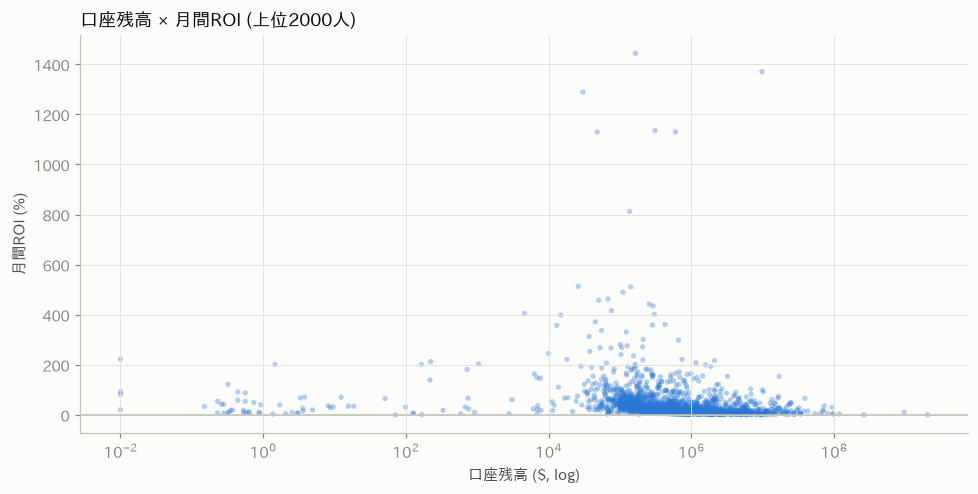

→ 右下 (大口・低ROI) は資金力で稼ぐタイプ、左上 (小口・高ROI) は技術で稼ぐタイプ。
  自分の資金規模に近い勝者を選んでパクるのが定石 (大口の1%リスクは小口の全損)。


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.6))
# 口座残高とROIの関係: 小口で高ROIの人が「パクる価値がある人」
d = lb[(lb["account_value"] > 0) & (lb["roi_month"].abs() < 50)]
ax.scatter(d["account_value"], d["roi_month"] * 100,
           s=12, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xscale("log")
ax.set_title("口座残高 × 月間ROI (上位2000人)", loc="left")
ax.set_xlabel("口座残高 ($, log)")
ax.set_ylabel("月間ROI (%)")
ax.axhline(0, color="#c3c2b7", lw=1)
plt.tight_layout()
plt.show()
print("→ 右下 (大口・低ROI) は資金力で稼ぐタイプ、左上 (小口・高ROI) は技術で稼ぐタイプ。\n"
      "  自分の資金規模に近い勝者を選んでパクるのが定石 (大口の1%リスクは小口の全損)。")

---
# §3 手法解剖 — 勝ち組は「何を・いつ・どれだけ」売買しているか

月間PnL上位200人 (口座$10k以上) の**直近30日の全約定**を取得した (`fills_topN.csv.gz`)。
1約定 = 銘柄・方向 (新規/決済×L/S)・価格・サイズ・実現PnL・taker/maker。

ここが「パクる」の本体。見るべきは:
- **銘柄選択**: 出来高が集まる銘柄 = 勝ち組が「戦える」と判断した銘柄
- **時間帯**: いつ動くか (Botか人間か、米国時間か)
- **サイズ・方向**: ロットと买卖の偏り
- **勝ちの源泉**: 実現PnLが出た銘柄 (出来高上位と稼ぎ頭は別物)

In [8]:
with gzip.open(DATA / "fills_topN.csv.gz", "rt") as f:
    fills = pd.read_csv(f)

# spot約定は "@107" のようなindex表記 → hl_meta.json で人間可読名に変換
hlmeta = json.loads((DATA / "hl_meta.json").read_text())
fills["coin"] = fills["coin"].map(lambda c: hlmeta["spot_pairs"].get(c, c))

fills["dt"] = pd.to_datetime(fills["time_ms"], unit="ms", utc=True).dt.tz_convert("Asia/Tokyo")
fills["notional"] = fills["px"] * fills["sz"]
fills["closed_pnl"] = pd.to_numeric(fills["closed_pnl"], errors="coerce").fillna(0)

n_addr = fills["address"].nunique()
print(f"約定数: {len(fills):,} / アドレス数: {n_addr} / "
      f"期間: {fills['dt'].min():%m-%d} 〜 {fills['dt'].max():%m-%d} (JST)")
print(f"総売買代金: ${fills['notional'].sum():,.0f}")
print(f"銘柄数: {fills['coin'].nunique()}")

約定数: 223,889 / アドレス数: 166 / 期間: 06-03 〜 07-03 (JST)
総売買代金: $8,699,381,334
銘柄数: 270


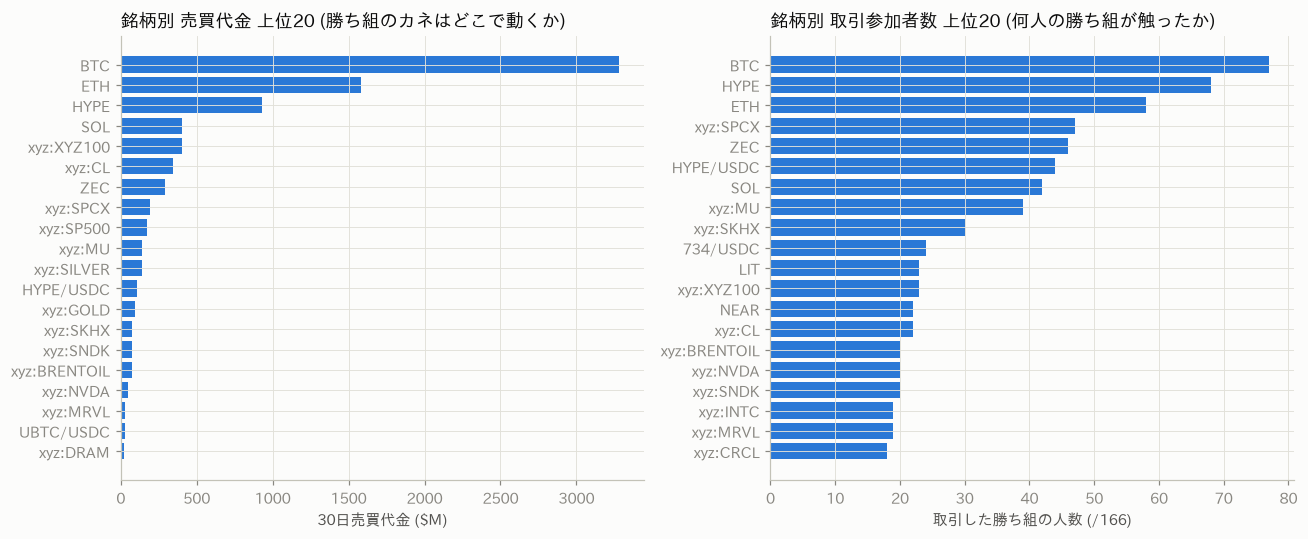

→ 左 (代金) は大口の主戦場、右 (人数) は「勝ち組の共通認識」。両方に出る銘柄が本命の監視対象。


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

by_ntl = fills.groupby("coin")["notional"].sum().nlargest(20).iloc[::-1]
axes[0].barh(by_ntl.index, by_ntl.values / 1e6, color=BLUE)
axes[0].set_title("銘柄別 売買代金 上位20 (勝ち組のカネはどこで動くか)", loc="left")
axes[0].set_xlabel("30日売買代金 ($M)")

by_addr = fills.groupby("coin")["address"].nunique().nlargest(20).iloc[::-1]
axes[1].barh(by_addr.index, by_addr.values, color=BLUE)
axes[1].set_title("銘柄別 取引参加者数 上位20 (何人の勝ち組が触ったか)", loc="left")
axes[1].set_xlabel(f"取引した勝ち組の人数 (/{n_addr})")
plt.tight_layout()
plt.show()
print("→ 左 (代金) は大口の主戦場、右 (人数) は「勝ち組の共通認識」。両方に出る銘柄が本命の監視対象。")

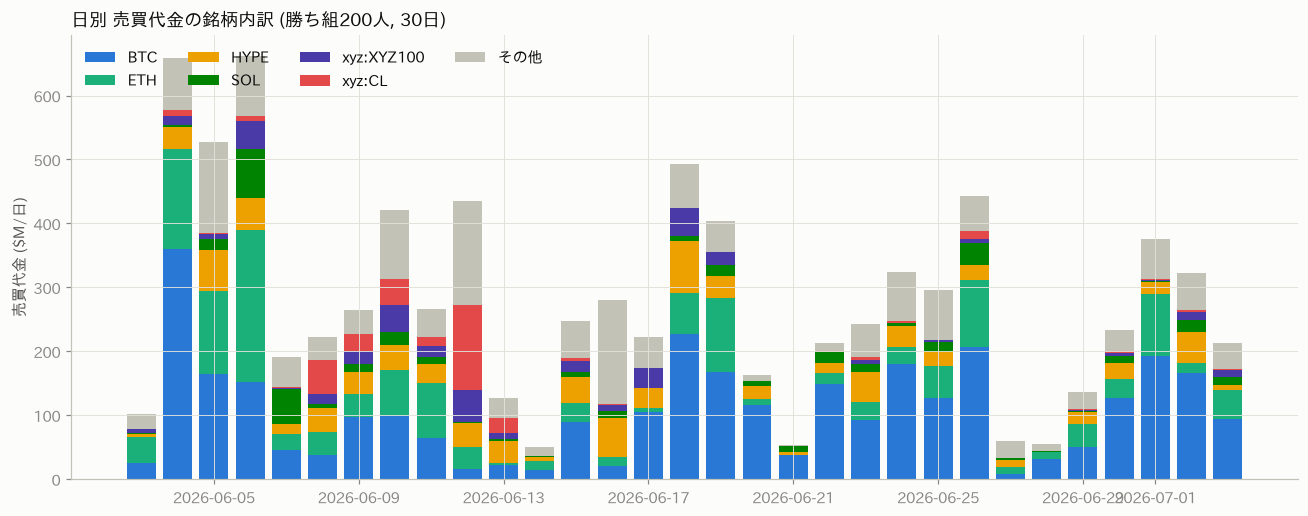

→ 特定の日に特定銘柄が突出する = イベントドリブン (上場/指標/ナラティブ)。突出日に何があったかを調べると彼らの情報源が見える。


In [10]:
# 日次 x 銘柄 (上位6 + その他): 「いつ・どの銘柄が」盛り上がったか
top6 = fills.groupby("coin")["notional"].sum().nlargest(6).index
daily = (fills.assign(day=fills["dt"].dt.floor("D"),
                      coin6=fills["coin"].where(fills["coin"].isin(top6), "その他"))
              .groupby(["day", "coin6"])["notional"].sum().unstack(fill_value=0)) / 1e6
order = [c for c in top6 if c in daily.columns] + ["その他"]
daily = daily[order]

fig, ax = plt.subplots(figsize=(12, 4.8))
bottom = np.zeros(len(daily))
for i, c in enumerate(daily.columns):
    color = GRAY if c == "その他" else C[i]
    ax.bar(daily.index, daily[c], bottom=bottom, width=0.8, label=c, color=color)
    bottom += daily[c].values
ax.set_title("日別 売買代金の銘柄内訳 (勝ち組200人, 30日)", loc="left")
ax.set_ylabel("売買代金 ($M/日)")
ax.legend(loc="upper left", ncols=4, frameon=False)
plt.tight_layout()
plt.show()
print("→ 特定の日に特定銘柄が突出する = イベントドリブン (上場/指標/ナラティブ)。"
      "突出日に何があったかを調べると彼らの情報源が見える。")

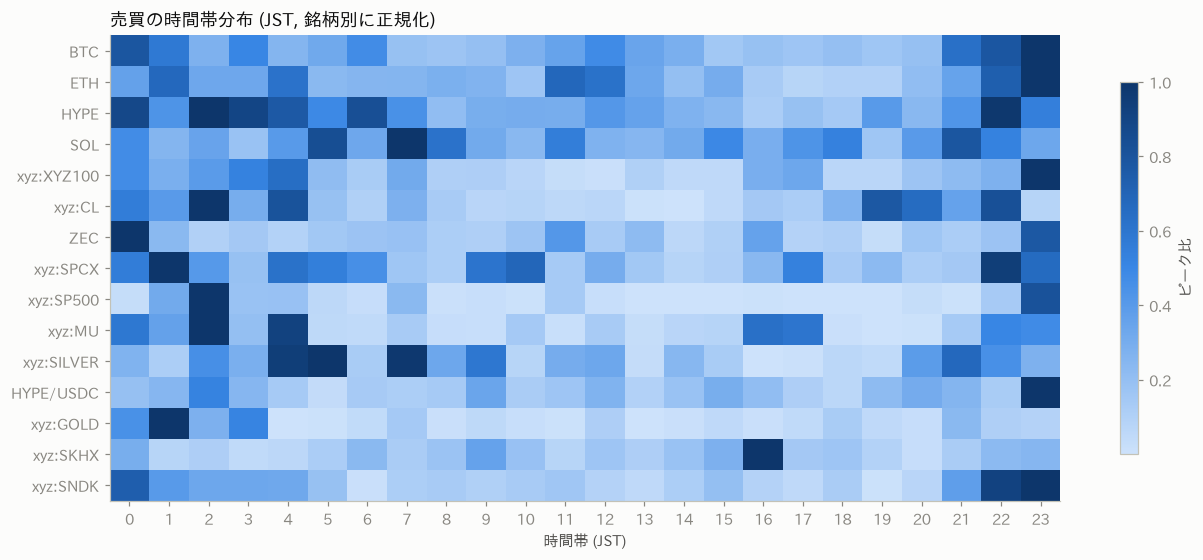

→ 日本の日中(9-15時JST)の代金シェア: 21%。濃い列 = 勝ち組が動く時間。自分が張り付くべき時間帯がこれで決まる。


In [11]:
# 時間帯ヒートマップ: 銘柄 (上位15) × JST時間帯
top15 = fills.groupby("coin")["notional"].sum().nlargest(15).index
hm = (fills[fills["coin"].isin(top15)]
      .assign(hour=fills["dt"].dt.hour)
      .groupby(["coin", "hour"])["notional"].sum().unstack(fill_value=0)
      .reindex(top15))
hm_norm = hm.div(hm.max(axis=1), axis=0)  # 銘柄ごとに正規化 (ピーク=1)

fig, ax = plt.subplots(figsize=(12, 5.2))
im = ax.imshow(hm_norm, aspect="auto", cmap=SEQ)
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(hm_norm)), labels=hm_norm.index)
ax.set_title("売買の時間帯分布 (JST, 銘柄別に正規化)", loc="left")
ax.set_xlabel("時間帯 (JST)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="ピーク比", shrink=0.8)
plt.tight_layout()
plt.show()
jp_share = fills[(fills["dt"].dt.hour >= 9) & (fills["dt"].dt.hour <= 15)]["notional"].sum() \
           / fills["notional"].sum() * 100
print(f"→ 日本の日中(9-15時JST)の代金シェア: {jp_share:.0f}%。"
      "濃い列 = 勝ち組が動く時間。自分が張り付くべき時間帯がこれで決まる。")

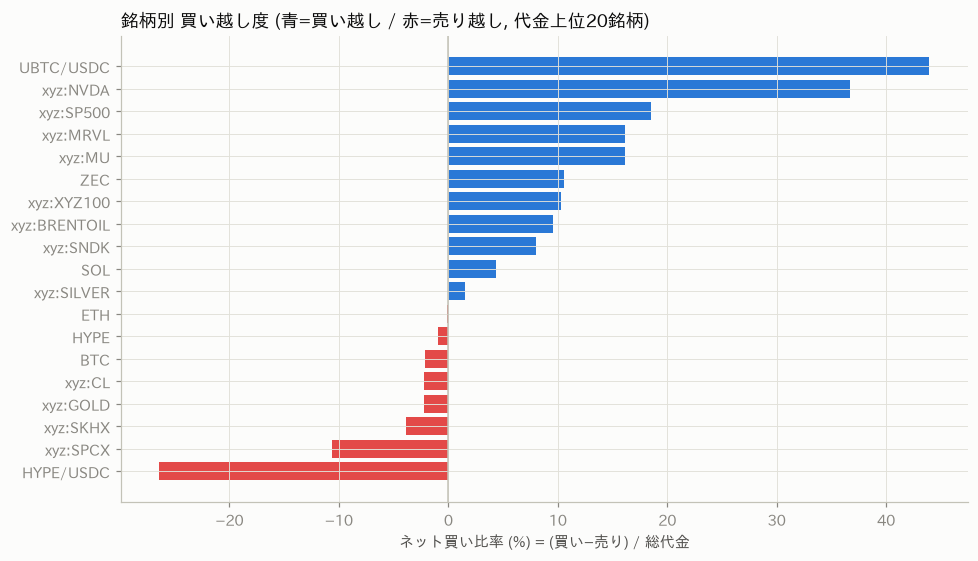

In [12]:
# 買い越し/売り越し (方向の偏り): B=buy, A=sell
imb = (fills.assign(signed=np.where(fills["side"] == "B",
                                    fills["notional"], -fills["notional"]))
             .groupby("coin").agg(net=("signed", "sum"), total=("notional", "sum")))
imb = imb[imb["total"] > imb["total"].nlargest(20).min()]
imb["ratio"] = imb["net"] / imb["total"] * 100
imb = imb.sort_values("ratio")

fig, ax = plt.subplots(figsize=(9, 5.2))
colors = [BLUE if v > 0 else RED for v in imb["ratio"]]
ax.barh(imb.index, imb["ratio"], color=colors)
ax.axvline(0, color="#c3c2b7", lw=1)
ax.set_title("銘柄別 買い越し度 (青=買い越し / 赤=売り越し, 代金上位20銘柄)", loc="left")
ax.set_xlabel("ネット買い比率 (%) = (買い−売り) / 総代金")
plt.tight_layout()
plt.show()

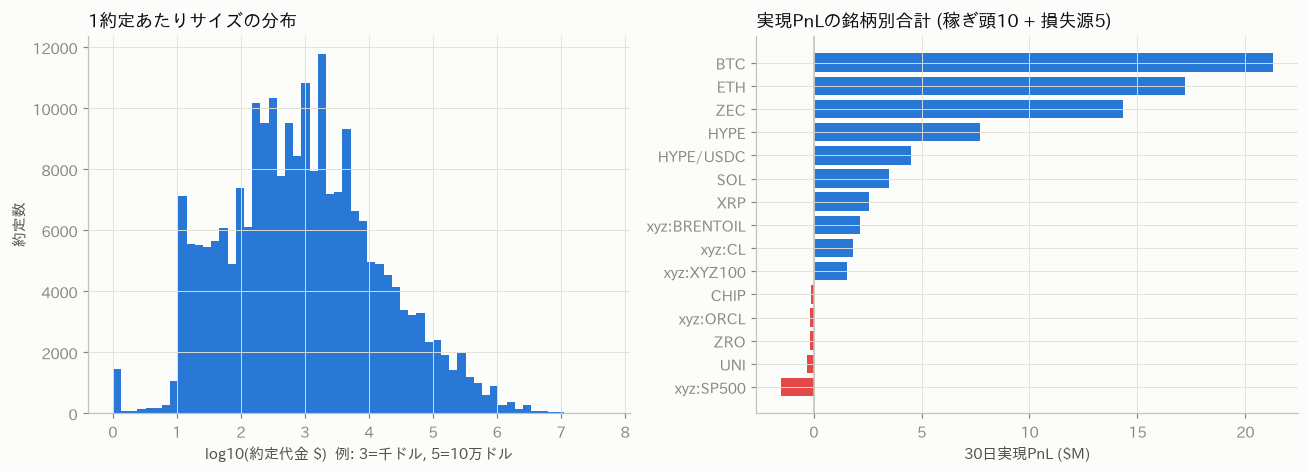

→ 「売買代金上位」と「稼ぎ頭」は一致しないことが多い。代金上位=主戦場、実現PnL上位=いま効いている銘柄。パクるなら後者を重視。


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# 1約定あたりのサイズ分布
axes[0].hist(np.log10(fills["notional"].clip(lower=1)), bins=60, color=BLUE)
axes[0].set_title("1約定あたりサイズの分布", loc="left")
axes[0].set_xlabel("log10(約定代金 $)  例: 3=千ドル, 5=10万ドル")
axes[0].set_ylabel("約定数")

# 実現PnLの銘柄別合計 (勝ちの源泉)
pnl = fills.groupby("coin")["closed_pnl"].sum()
pnl = pd.concat([pnl.nlargest(10), pnl.nsmallest(5)]).sort_values()
colors = [BLUE if v > 0 else RED for v in pnl.values]
axes[1].barh(pnl.index, pnl.values / 1e6, color=colors)
axes[1].axvline(0, color="#c3c2b7", lw=1)
axes[1].set_title("実現PnLの銘柄別合計 (稼ぎ頭10 + 損失源5)", loc="left")
axes[1].set_xlabel("30日実現PnL ($M)")
plt.tight_layout()
plt.show()
print("→ 「売買代金上位」と「稼ぎ頭」は一致しないことが多い。"
      "代金上位=主戦場、実現PnL上位=いま効いている銘柄。パクるなら後者を重視。")

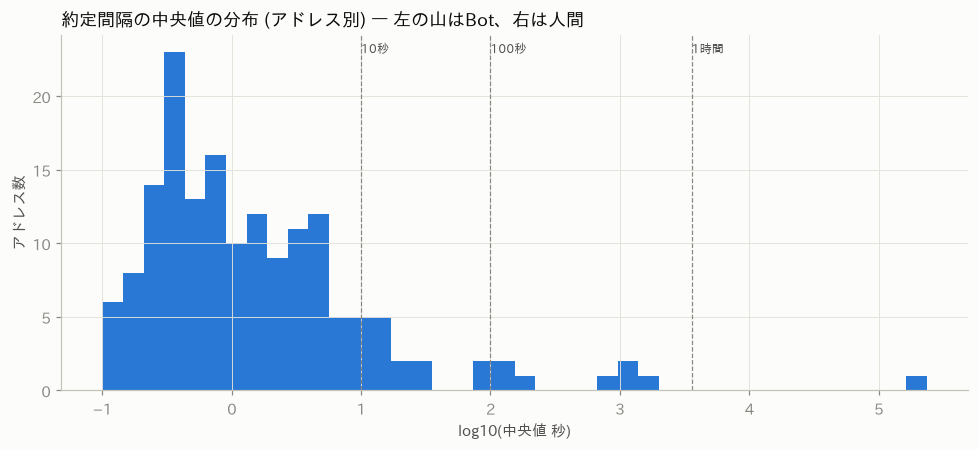

→ 中央値60秒未満 (Bot/MM濃厚): 153/163人。
  Botの執行はパクれない (レイテンシで負ける)。パクるのは銘柄選択と方向だけ。
  human側 (右の山) のアドレスを深追いする方が実り多い。


In [14]:
# Bot vs 人間の見分け: 約定間隔の中央値 (アドレス別)
gaps = (fills.sort_values("time_ms").groupby("address")["time_ms"]
             .apply(lambda s: s.diff().median() / 1000))
gaps = gaps.dropna()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(np.log10(gaps.clip(lower=0.1)), bins=40, color=BLUE)
for x, lab in [(1, "10秒"), (2, "100秒"), (3.556, "1時間")]:
    ax.axvline(x, color="#898781", lw=0.8, ls="--")
    ax.text(x, ax.get_ylim()[1] * 0.95, lab, fontsize=8, color="#52514e", ha="left")
ax.set_title("約定間隔の中央値の分布 (アドレス別) — 左の山はBot、右は人間", loc="left")
ax.set_xlabel("log10(中央値 秒)")
ax.set_ylabel("アドレス数")
plt.tight_layout()
plt.show()

bots = (gaps < 60).sum()
print(f"→ 中央値60秒未満 (Bot/MM濃厚): {bots}/{len(gaps)}人。\n"
      "  Botの執行はパクれない (レイテンシで負ける)。パクるのは銘柄選択と方向だけ。\n"
      "  human側 (右の山) のアドレスを深追いする方が実り多い。")

---
# §4 今の張り方 — スマートマネーの現在ポジション

上位200人の**現在のperpポジション**のスナップショット (`positions_topN.csv`)。
「勝ち組の総意」がどの銘柄のどっち向きに傾いているかを見る。

**注意**: これは収集時点のスナップショット。§5のBotはこれを定期取得して**変化**を通知する。

ポジション数: 1,022 / 保有者数: 118


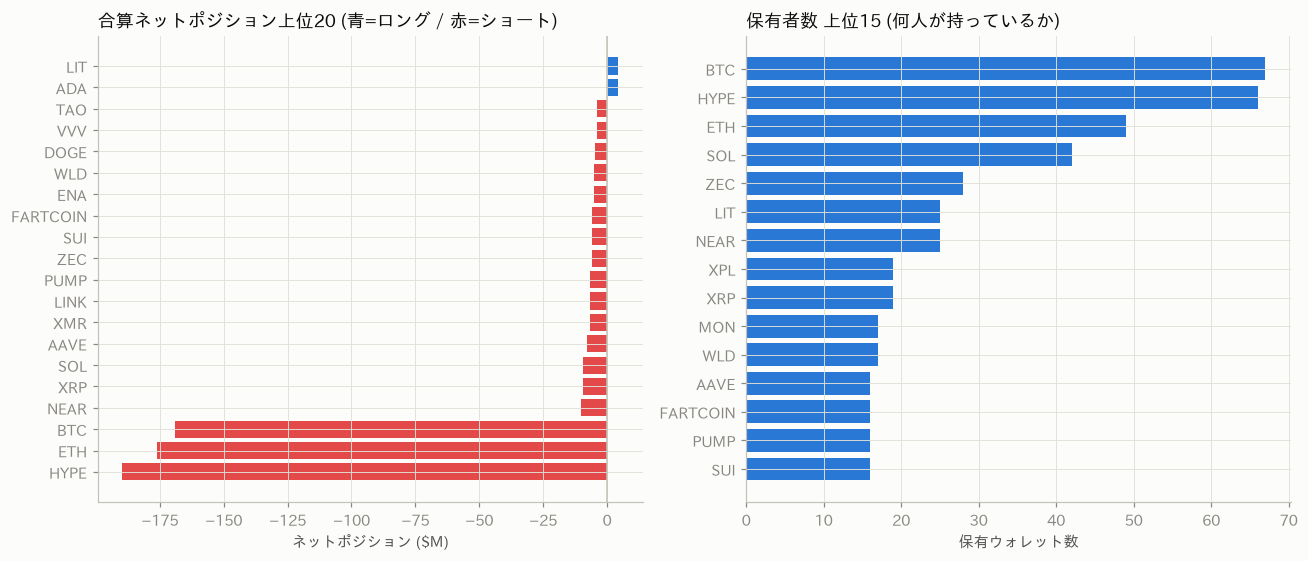

→ 金額の偏りは1人の大口で作られることがある。左右両方で上位の銘柄が「本当の総意」。


In [15]:
pos = pd.read_csv(DATA / "positions_topN.csv")
pos["szi"] = pd.to_numeric(pos["szi"], errors="coerce")
pos["position_value"] = pd.to_numeric(pos["position_value"], errors="coerce").abs()
pos["signed_usd"] = np.where(pos["szi"] > 0, pos["position_value"], -pos["position_value"])
print(f"ポジション数: {len(pos):,} / 保有者数: {pos['address'].nunique()}")

net = pos.groupby("coin")["signed_usd"].sum()
net = net.reindex(net.abs().nlargest(20).index).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
colors = [BLUE if v > 0 else RED for v in net.values]
axes[0].barh(net.index, net.values / 1e6, color=colors)
axes[0].axvline(0, color="#c3c2b7", lw=1)
axes[0].set_title("合算ネットポジション上位20 (青=ロング / 赤=ショート)", loc="left")
axes[0].set_xlabel("ネットポジション ($M)")

holders = pos.groupby("coin")["address"].nunique().nlargest(15).iloc[::-1]
axes[1].barh(holders.index, holders.values, color=BLUE)
axes[1].set_title("保有者数 上位15 (何人が持っているか)", loc="left")
axes[1].set_xlabel("保有ウォレット数")
plt.tight_layout()
plt.show()
print("→ 金額の偏りは1人の大口で作られることがある。左右両方で上位の銘柄が「本当の総意」。")

---
# §5 シグナル化 — 通知Botのロジックと過去30日の検証

## 実装済みBot: `smart_money_tracker.py` (+ `.github/workflows/smart-money-tracker.yml`)

1時間ごとに上位100ウォレットの現在ポジションを取得し、前回との**差分**から
「**コンセンサス新規参入**」を検知して Discord に通知する:

```
条件: 前回スキャン以降に MIN_WALLETS(既定2)人以上が
      同一銘柄・同方向に $10k以上の新規ポジションを建てた
      (クールダウン12h / 初回実行は基準保存のみ / 履歴は smart_money_signals_log.csv)
追跡対象: tracked_addresses.csv の非Botウォレット (最大100人)
      (収集時に約定間隔からMM/HFT Botを自動判定して除外。§3で見た通り
       上位勢の9割はBotであり、Botの執行はパクれないため)
```

必要な設定はリポジトリSecretsの `DISCORD_WEBHOOK_URL` だけ (既存Botと同じ)。
scheduleはmainマージ後に有効。追跡リストは月1回 Smart Money Collect を回して更新する。

## 閾値の根拠 — 過去30日で何回・何を検知したか (シミュレーション)

約定データから「6時間以内にK人以上が同一銘柄・同方向に新規オープン」を数える。
**Bot込み/Bot除外 × 人数閾値**でスイープすると、既定値 (Bot除外・2人) の根拠が見える。

新規オープン約定: 全体21,438件 / 人間のみ861件 (アクティブな人間: 5人)
閾値スイープ (30日間の発火回数):
  Bot込み × 2人以上:  477回 (銘柄33)
  Bot込み × 3人以上:  199回 (銘柄8)
  Bot込み × 4人以上:  109回 (銘柄5)
  Bot除外 × 2人以上:   17回 (銘柄4)
  Bot除外 × 3人以上:    0回 (銘柄0)
  Bot除外 × 4人以上:    0回 (銘柄0)
→ Bot込みは鳴りっぱなし、Bot除外×3人は無音。**Bot除外×2人 (既定)** が実用域。


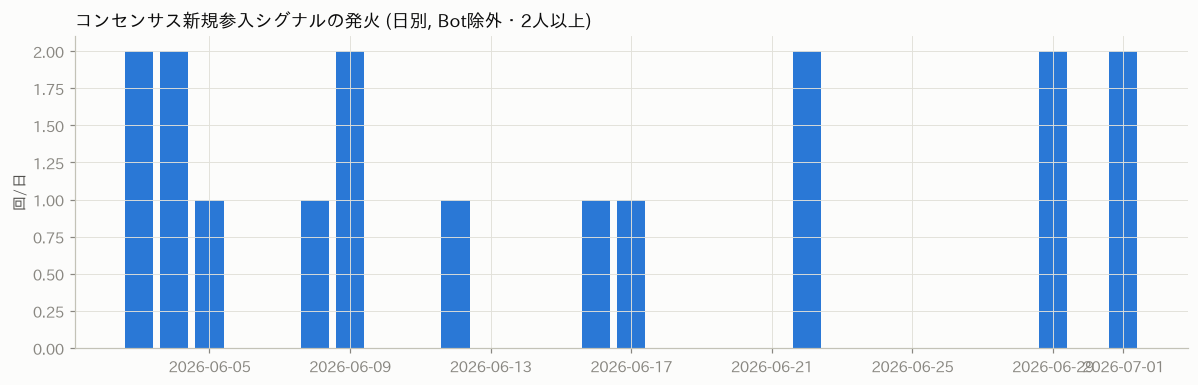


発火の内訳 (新しい順):


,window,coin,side_ls,人数,合計$M
288,2026-07-01 18:00:00+09:00,BTC,SHORT,2,2.82
283,2026-07-01 06:00:00+09:00,BTC,LONG,2,10.89
264,2026-06-29 18:00:00+09:00,HYPE,SHORT,2,1.08
262,2026-06-29 18:00:00+09:00,BTC,SHORT,2,3.23
173,2026-06-22 06:00:00+09:00,xyz:BRENTOIL,LONG,2,0.55
168,2026-06-22 00:00:00+09:00,HYPE,SHORT,2,0.37
144,2026-06-17 18:00:00+09:00,HYPE,SHORT,2,0.71
129,2026-06-16 00:00:00+09:00,BTC,SHORT,2,3.44
102,2026-06-12 18:00:00+09:00,ZEC,SHORT,2,0.72
69,2026-06-09 18:00:00+09:00,ZEC,SHORT,2,0.71


In [16]:
bot_addrs = set(gaps[gaps < 60].index)  # §3のBot判定 (約定間隔中央値<60秒)

def simulate(df, min_wallets):
    ev = (df.groupby(["window", "coin", "side_ls"])
            .agg(wallets=("address", "nunique"), usd=("notional", "sum"))
            .reset_index())
    return ev[ev["wallets"] >= min_wallets].sort_values("window")

opens = fills[fills["dir"].str.startswith("Open", na=False)].copy()
opens["side_ls"] = np.where(opens["dir"] == "Open Long", "LONG", "SHORT")
opens = opens[opens["notional"] >= 10_000]  # Bot本体と同じノイズ除外
opens["window"] = opens["dt"].dt.floor("6h")
humans = opens[~opens["address"].isin(bot_addrs)]

print(f"新規オープン約定: 全体{len(opens):,}件 / 人間のみ{len(humans):,}件 "
      f"(アクティブな人間: {humans['address'].nunique()}人)")
print("閾値スイープ (30日間の発火回数):")
for label, df in [("Bot込み", opens), ("Bot除外", humans)]:
    for mw in (2, 3, 4):
        ev_ = simulate(df, mw)
        print(f"  {label} × {mw}人以上: {len(ev_):4d}回 (銘柄{ev_['coin'].nunique()})")
print("→ Bot込みは鳴りっぱなし、Bot除外×3人は無音。**Bot除外×2人 (既定)** が実用域。")

ev = simulate(humans, 2)
daily_fires = ev.groupby(ev["window"].dt.floor("D")).size()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(daily_fires.index, daily_fires.values, width=0.8, color=BLUE)
ax.set_title("コンセンサス新規参入シグナルの発火 (日別, Bot除外・2人以上)", loc="left")
ax.set_ylabel("回/日")
plt.tight_layout()
plt.show()

print("\n発火の内訳 (新しい順):")
ev.tail(17).iloc[::-1].assign(usd=lambda d: (d["usd"]/1e6).round(2)) \
  .rename(columns={"usd": "合計$M", "wallets": "人数"})

**発火頻度の読み方**: 既定 (Bot除外・2人) で約0.5回/日 — 通知として機能する頻度。
多すぎる場合は `MIN_POS_USD` を$50kに上げる。少なすぎる場合の本質的な改善は
**追跡する人間を増やす**こと: 収集の `FILLS_N` を200→500に上げる、または
ランキングを月間PnLではなくROI×出来高下限に変えると、中規模の人間トレーダーが
リストに入りやすくなる (現状の月間PnL上位はMM Botに占拠されているため)。

---
# まとめ — この教材で身につけるべき「型」

1. **戦場選び (§1)**: DefiLlamaで出来高・手数料の集中先を月1で確認。戦場が枯れたら移る。
2. **選球眼 (§2)**: 戦場の公式リーダーボードで「いま勝っている人」を機械的に抽出。
   PnL集中度から、実務は上位100〜200人の深追いで十分。
3. **手法解剖 (§3)**: 勝ち組の銘柄選択・時間帯・サイズ・稼ぎ頭を可視化。
   Botはパクれない。**パクるのは銘柄リストと方向**。
4. **総意の変化 (§4→§5)**: スナップショットではなく「変化」がシグナル。
   コンセンサス新規参入をBotで通知し、履歴CSVで後検証する。

## 限界と正直な注意 (docs/DEFILLAMA_GUIDE.md §2-4 も参照)

- 月間PnL上位は生存バイアスを含む (今月のハイレバ勝者)。定期的な入れ替えが前提。
- fillsは事後データ。追随は常に彼らより悪い価格。シグナルは「監視リスト入り候補」であって
  エントリー命令ではない (RULES.md の原則通り、FGI/FRなど既存シグナルとの合流で使う)。
- Hyperliquid以外の戦場 (現物DEX、ミーム) の勝者は別の収集器が必要。DuneやBirdeyeが候補 (ガイド参照)。

## 再実行の手順

1. GitHub → Actions → **Smart Money Collect** → Run workflow (データ更新, 約15分)
2. このノートを上から実行 (`jupyter lab notebooks/smart_money_analysis.ipynb`)
3. 必要パッケージ: `pip install pandas matplotlib matplotlib-fontja`